# Notebook 09 - Uncertainty Quantification (Second version)

City-agnostic improved workflow for **Lisbon**. This version keeps the original March 2026 `NB09` untouched and adds three targeted improvements:
- spatially explicit daily raster modifiers for trees and waste heat
- event-level warning-day logic for EWS
- EWS CBA uncertainty outputs alongside the impact uncertainty outputs

All new outputs are written to `outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast/` so the original `NB09` outputs remain unchanged.


In [1]:
import os
os.environ["URBAN_HEAT_OUTPUT_VARIANT"] = "masselot_main"
os.environ["IF_MAIN_FAMILY"] = "masselot_tail"


In [2]:
import os
import sys
from pathlib import Path

os.environ.setdefault('CITY', 'lisbon')
os.environ.setdefault('NB09_N', '512')
os.environ.setdefault('NB09_SEED', '42')
os.environ.setdefault('NB09_MAKE_FIGURES', '0')
os.environ.setdefault('HAZARD_TRACK', 'standard')

def _find_repo_root():
    env = os.environ.get("URBAN_HEAT_ROOT")
    if env:
        root = Path(env).expanduser().resolve()
        if (root / "cityheat").is_dir() and (root / "configs").is_dir():
            return root
    start = Path.cwd().resolve()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError(
        "Could not locate repo root. Run the notebook from inside the repo "
        "or set URBAN_HEAT_ROOT."
    )

ROOT = _find_repo_root()
output_variant = os.environ.get('URBAN_HEAT_OUTPUT_VARIANT', '').strip()
if not output_variant:
    raise RuntimeError('Masselot-main NB09 requires URBAN_HEAT_OUTPUT_VARIANT.')
OUTPUT_ROOT = ROOT / 'outputs_variants' / output_variant
os.environ.setdefault('MPLCONFIGDIR', str(OUTPUT_ROOT / '.mpl'))
os.environ.setdefault('XDG_CACHE_HOME', str(OUTPUT_ROOT / '.cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)
print('CITY:', os.environ['CITY'])
print('NB09_N:', os.environ['NB09_N'])
print('NB09_SEED:', os.environ['NB09_SEED'])


ROOT: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat
CITY: lisbon
NB09_N: 512
NB09_SEED: 42


In [3]:
import logging, warnings, os
warnings.filterwarnings('ignore', category=FutureWarning)
for _name in ['climada', 'climada.hazard', 'climada.hazard.base', 'SALib']:
    logging.getLogger(_name).setLevel(logging.ERROR)
print('NB09 Masselot-main full run: city=lisbon, N=512, seed=42, figures enabled')
print('URBAN_HEAT_OUTPUT_VARIANT=', os.environ.get('URBAN_HEAT_OUTPUT_VARIANT'))
print('IF_MAIN_FAMILY=', os.environ.get('IF_MAIN_FAMILY'))

NB09 Masselot-main full run: city=lisbon, N=512, seed=42, figures enabled
URBAN_HEAT_OUTPUT_VARIANT= masselot_main
IF_MAIN_FAMILY= masselot_tail


In [4]:
from cityheat.nb09_improved_fast_masselot_main import run_nb09_improved_fast

paths = run_nb09_improved_fast()
paths


[NB09 masselot-main] Run type: masselot_headline_lhs_band — Masselot extrapolation-bracketed LHS over ['masselot_tail', 'masselot']; output dir: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast


[lisbon] sample 1/512: year=2050 aai=0.153


[lisbon] sample 2/512: year=2040 aai=0.154


[lisbon] sample 3/512: year=2040 aai=0.095


[lisbon] sample 4/512: year=2020 aai=0.105


...

[lisbon] sample 512/512: year=2020 aai=0.000


/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

{'headline_unc_dir': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast'),
 'headline__samples': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast/unc_samples_lisbon_improved_fast.csv'),
 'samples': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast/unc_samples_lisbon_improved_fast.csv'),
 'headline__impact': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast/unc_impact_summary_lisbon_improved_fast.csv'),
 'impact': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast/unc_impact_summary_lisbon_improved_fast.csv

In [5]:
import pandas as pd

samples = pd.read_csv(paths['samples'])
samples[[
    'year', 'aai_agg', 'annual_deaths', 'sample_warning_days',
    'sample_threshold_deaths_per_day', 'ews_pv_cost_25y',
    'ews_net_avoided_deaths_25y_cum', 'ews_cost_per_net_death_25y_cum'
]].head(10)

,year,aai_agg,annual_deaths,sample_warning_days,sample_threshold_deaths_per_day,ews_pv_cost_25y,ews_net_avoided_deaths_25y_cum,ews_cost_per_net_death_25y_cum
0,2050,0.153388,55.986549,63.0,0.417030,9.544381e+06,31.942835,298795.680199
1,2040,0.153675,56.245227,46.0,0.535299,3.541517e+06,74.829080,47328.089688
2,2040,0.095284,34.874092,34.0,0.408364,9.586249e+06,41.447559,231286.225239
3,2020,0.105251,38.521991,15.0,0.613161,2.432543e+06,167.046639,14562.060971
4,2050,0.134520,49.099899,53.0,0.368186,2.228643e+07,66.402337,335627.222957
5,2040,0.067981,24.881138,16.0,0.430147,1.046905e+06,54.061848,19364.952289
6,2050,0.087314,31.869476,52.0,0.267054,3.048637e+06,25.347800,120272.271800
7,2040,0.112013,40.996680,42.0,0.462792,3.233046e+06,125.639645,25732.691938
8,2050,0.168418,61.472584,58.0,0.439051,2.988132e+06,43.035610,69433.940930
9,2020,0.083261,30.473523,23.0,0.394162,3.284988e+06,24.036193,136668.400270


In [6]:
impact_summary = pd.read_csv(paths['impact'])
cba_summary = pd.read_csv(paths['cba'])

display(impact_summary.describe())
display(cba_summary.describe())

,aai_agg,annual_deaths,rp2,rp5,rp10,rp20
count,512.000000,512.000000,512.000000,512.000000,512.000000,512.000000
mean,0.116163,42.454815,0.000186,0.209822,0.429037,0.581946
std,0.038723,14.141879,0.000257,0.093151,0.138487,0.183395
min,0.049239,17.972251,0.000003,0.075473,0.180582,0.269203
25%,0.088748,32.481820,0.000046,0.143424,0.329395,0.457991
50%,0.107366,39.262316,0.000077,0.184000,0.398354,0.538232
75%,0.134307,49.102826,0.000246,0.245850,0.496284,0.667324
max,0.304243,111.352954,0.002680,0.631231,1.121916,1.492932


,ews_pv_cost_25y,ews_net_avoided_deaths_25y_cum,ews_net_avoided_deaths_25y_pv,ews_cost_per_net_death_25y_cum,ews_cost_per_net_death_25y_pv,ews_life_years_saved_25y_cum
count,5.120000e+02,512.000000,512.000000,5.120000e+02,5.120000e+02,512.000000
mean,7.149700e+06,56.736103,35.807357,1.980613e+05,3.079752e+05,769.474955
std,5.475664e+06,48.812302,31.859067,2.104294e+05,3.103993e+05,668.935564
min,7.207462e+05,3.367715,1.758732,1.253277e+04,1.682669e+04,42.953286
25%,2.734665e+06,24.544373,15.366723,6.171003e+04,9.983841e+04,328.181563
50%,4.754036e+06,43.833056,26.795237,1.203764e+05,1.914226e+05,583.821686
75%,1.135212e+07,69.220066,43.989947,2.529001e+05,3.995401e+05,940.700052
max,3.090285e+07,341.506696,255.725557,1.238325e+06,1.665542e+06,4742.357929


## Masselot-main NB09 output paths

- bundle: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast/unc_impact_lisbon_march2026_improved_fast.h5

- bundle_sens: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast/unc_impact_lisbon_march2026_improved_fast_with_sensitivity.h5

- burke_sensitivity_burke_polynomial__bundle: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_burke_sensitivity/burke_polynomial/unc_impact_lisbon_march2026_improved_fast.h5

- burke_sensitivity_burke_polynomial__bundle_sens: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_burke_sensitivity/burke_polynomial/unc_impact_lisbon_march2026_improved_fast_with_sensitivity.h5

...

- vuln: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/lisbon/tables/uncertainty_improved_fast/unc_vulnerability_lisbon_improved_fast.csv

## Headline sample IF-family counts

,n
if_family,
masselot,256
masselot_tail,256


## Generated headline NB09 figures

### unc_distribution_aai_agg_lisbon_improved_fast.png

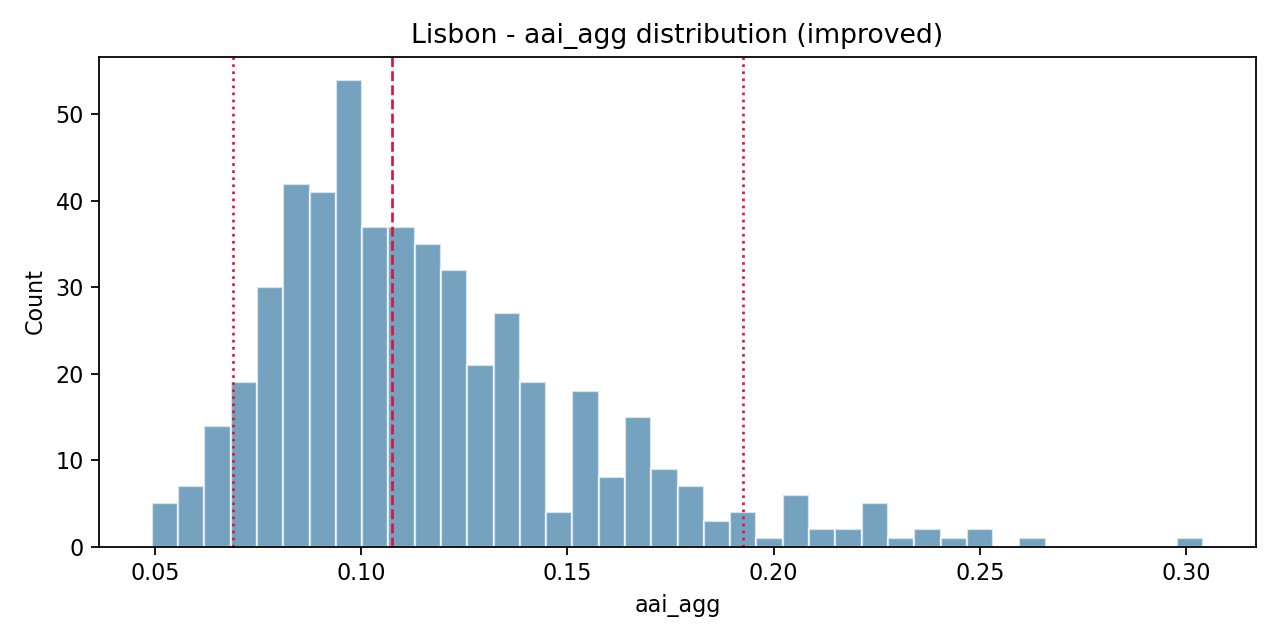

### unc_cdf_aai_agg_lisbon_improved_fast.png

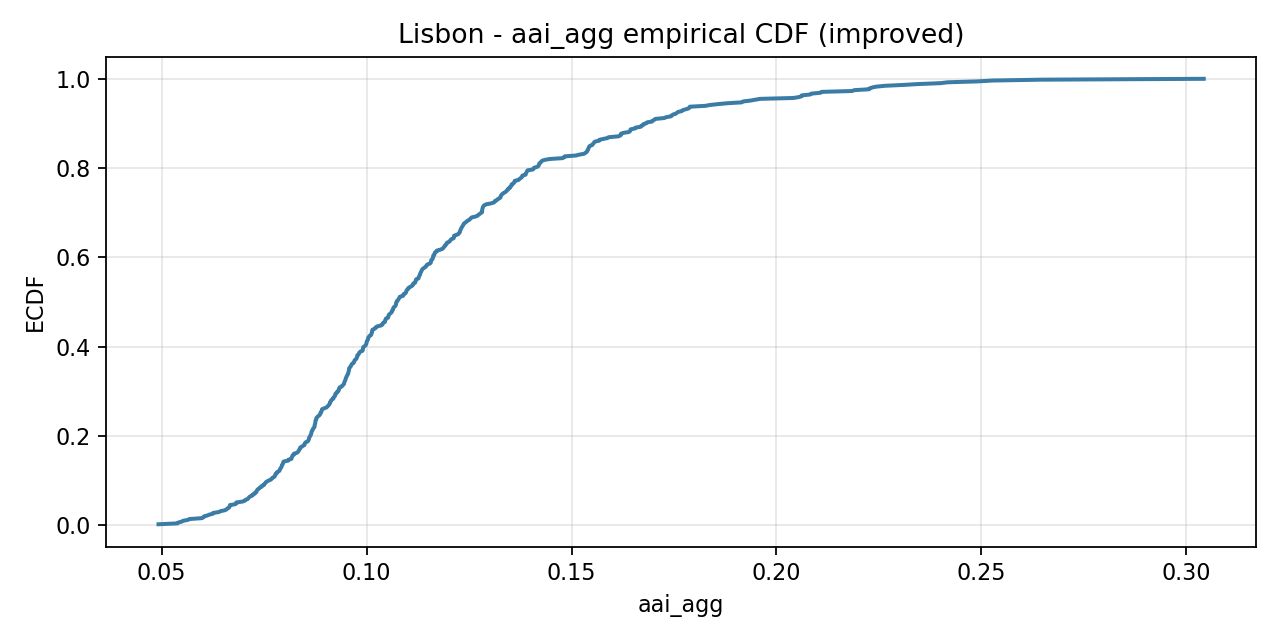

### sens_tornado_aai_agg_lisbon_improved_fast.png

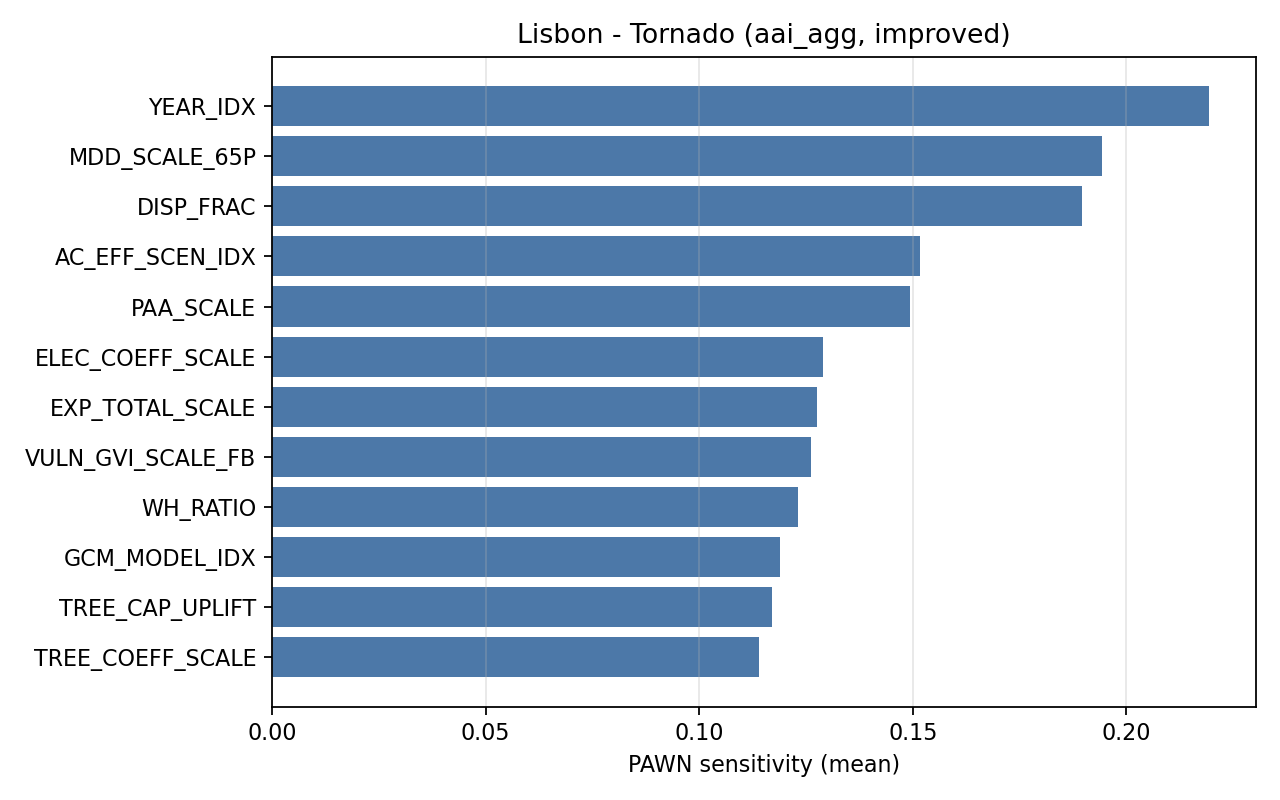

### unc_distribution_cba_ews_lisbon_improved_fast.png

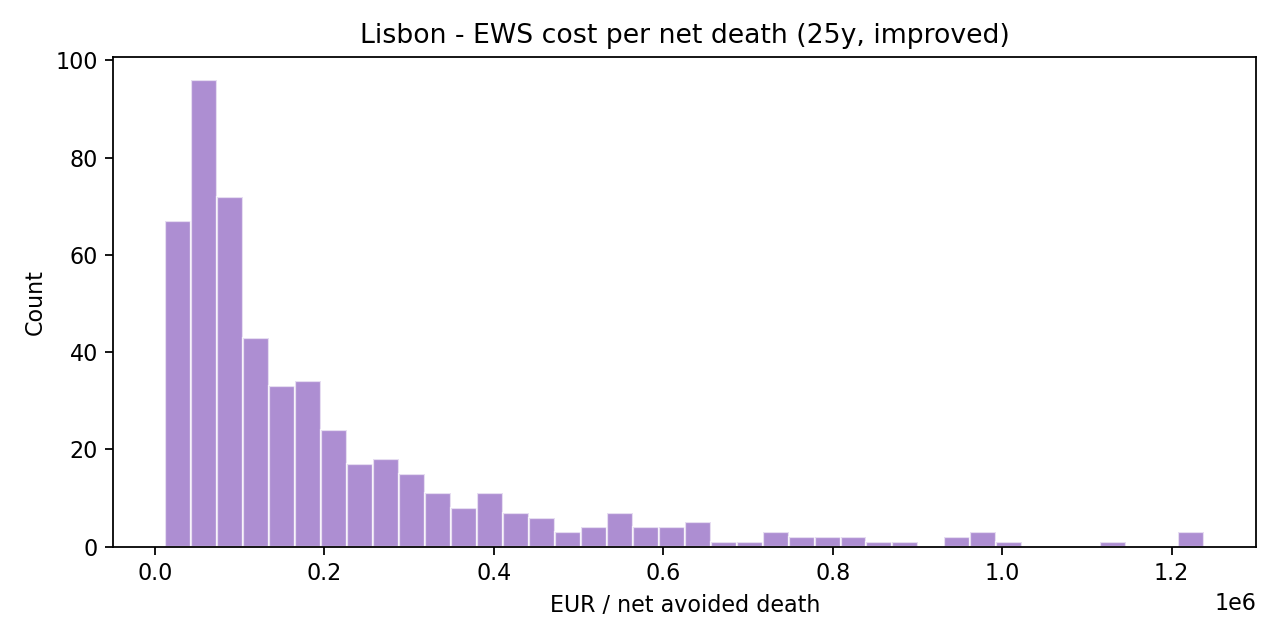

### unc_cdf_cba_ews_lisbon_improved_fast.png

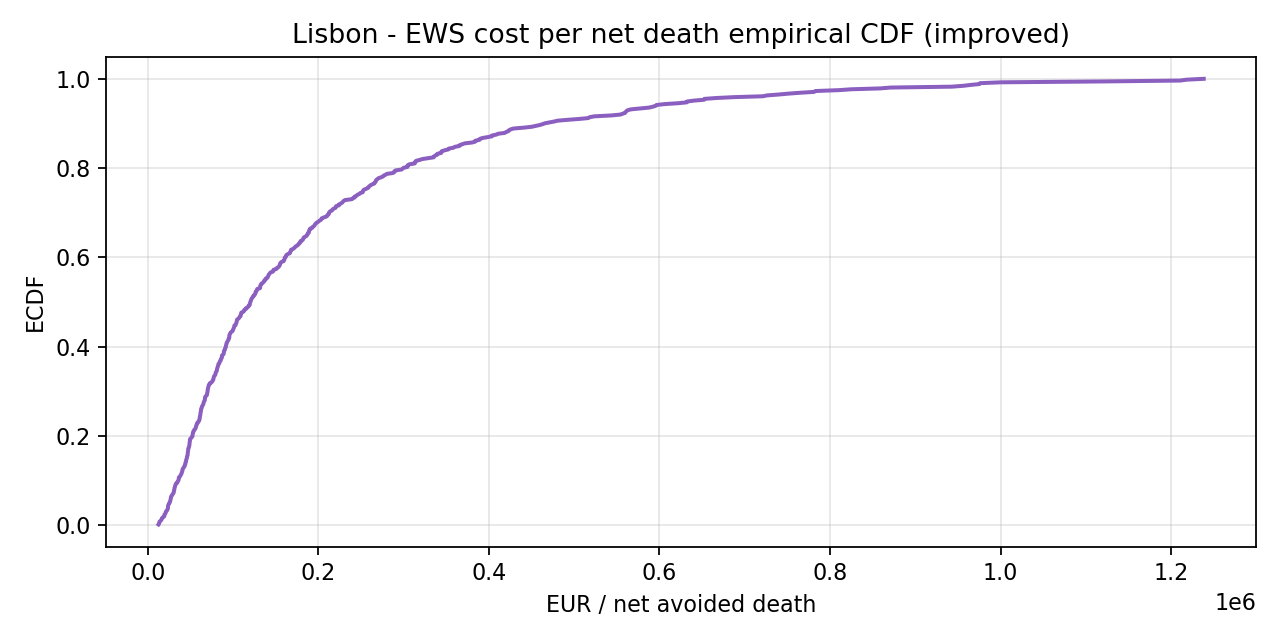

### sens_tornado_cba_ews_lisbon_improved_fast.png

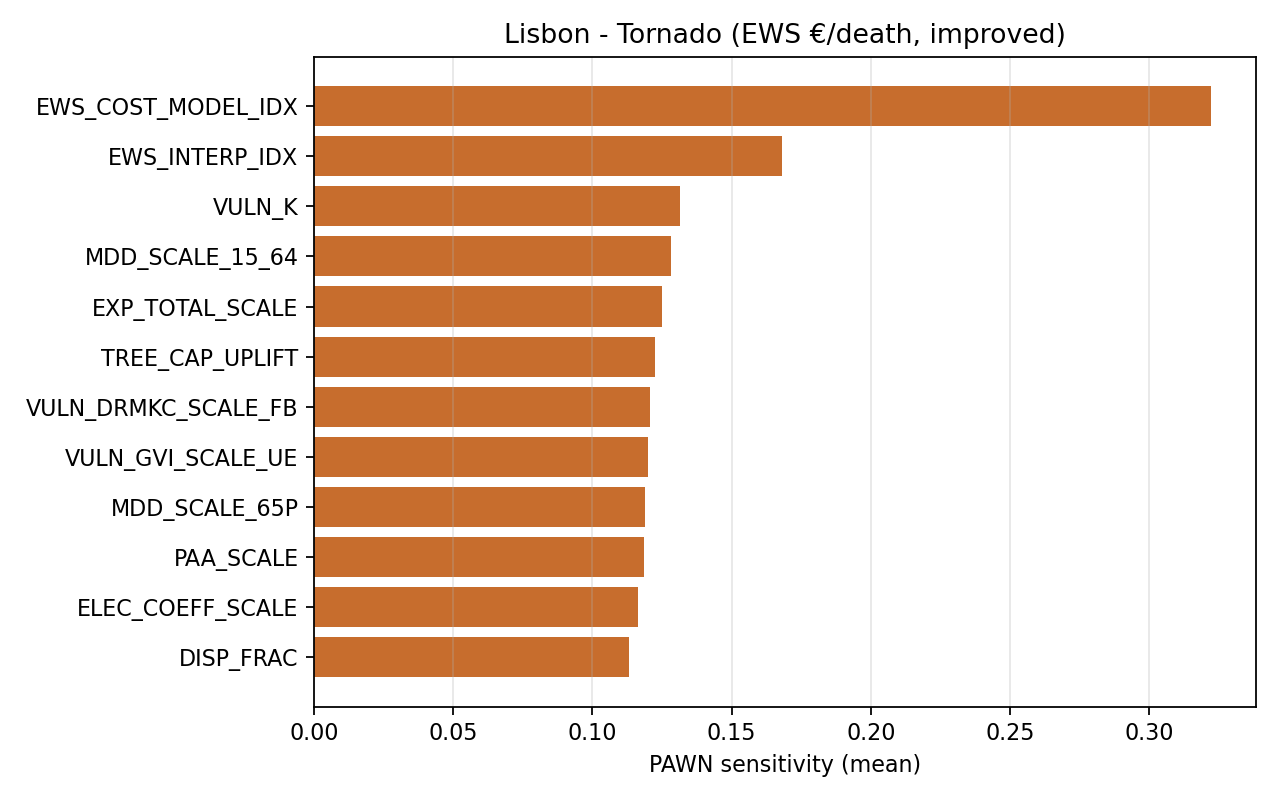

### unc_freq_curve_lisbon_improved_fast.png

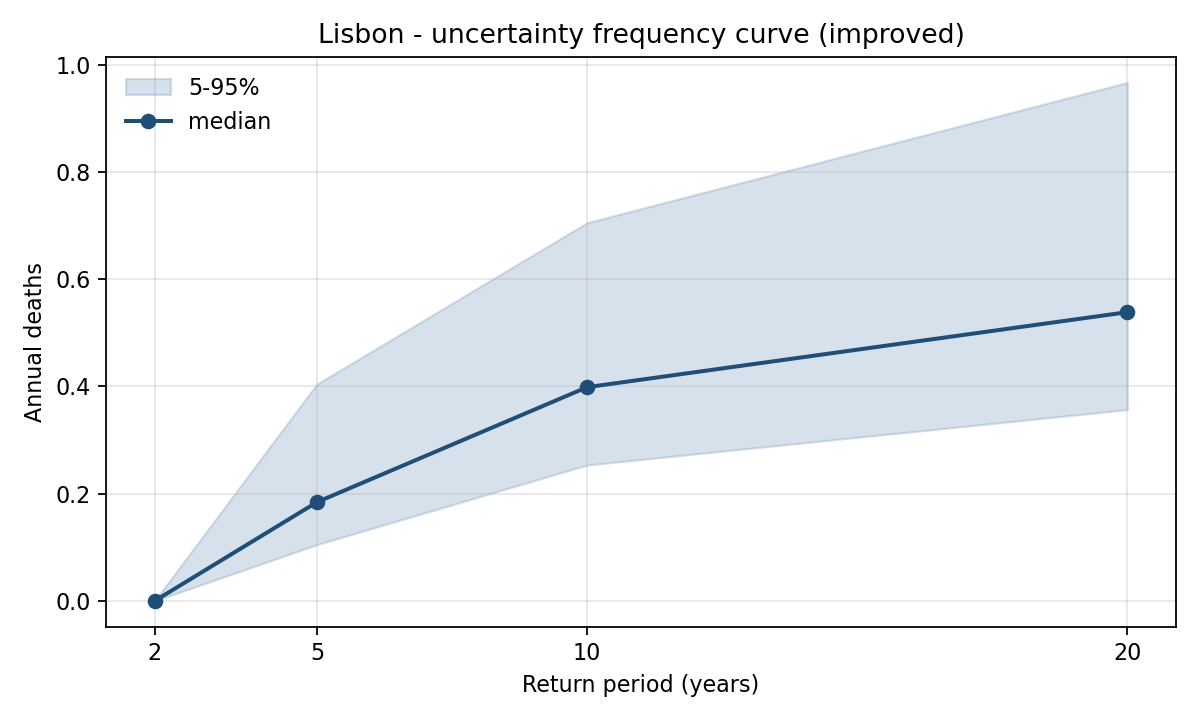

### unc_distribution_vuln_svi_mean_lisbon_improved_fast.png

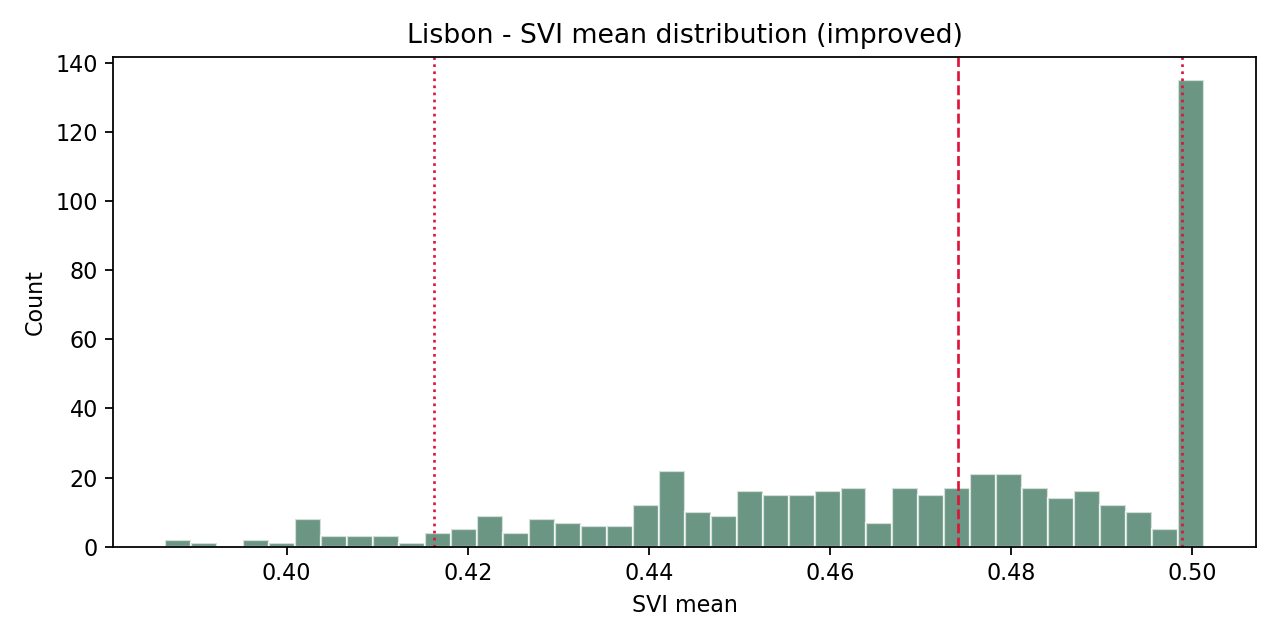

### unc_distribution_vuln_2050_svi_mean_lisbon_improved_fast.png

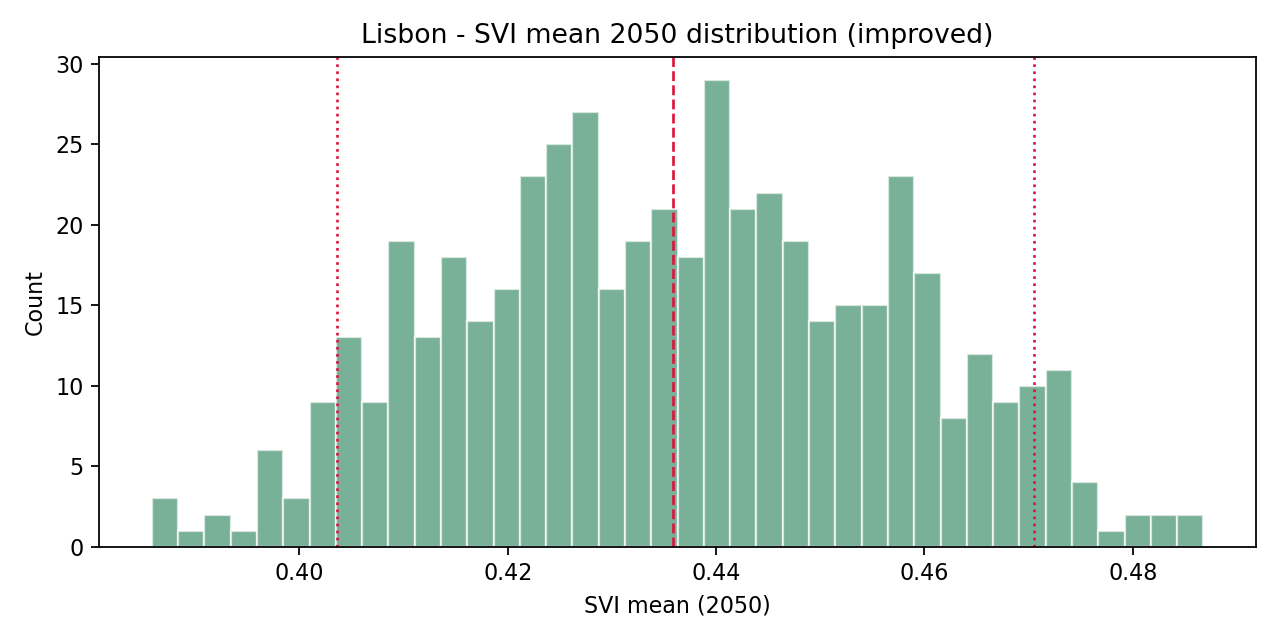

### sens_tornado_vuln_svi_gap_lisbon_improved_fast.png

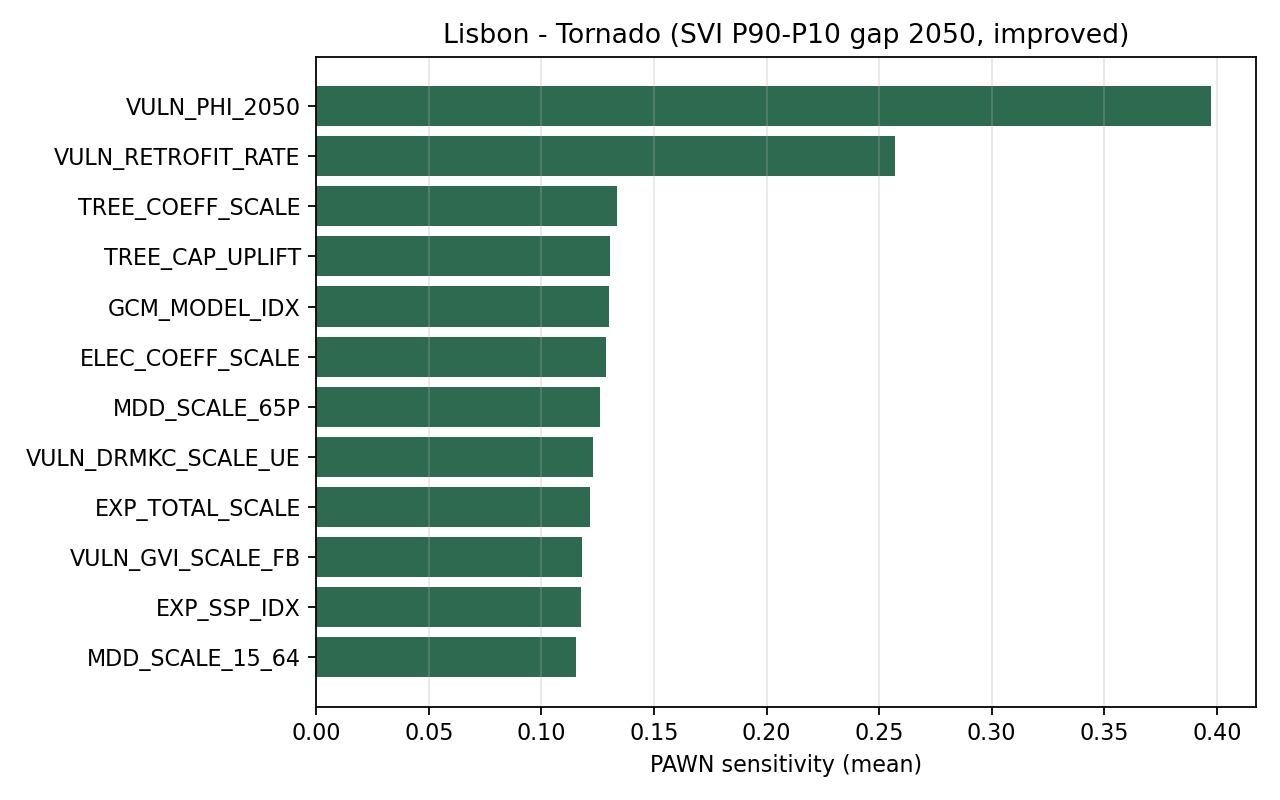

### sens_tornado_vuln_svi_mean_lisbon_improved_fast.png

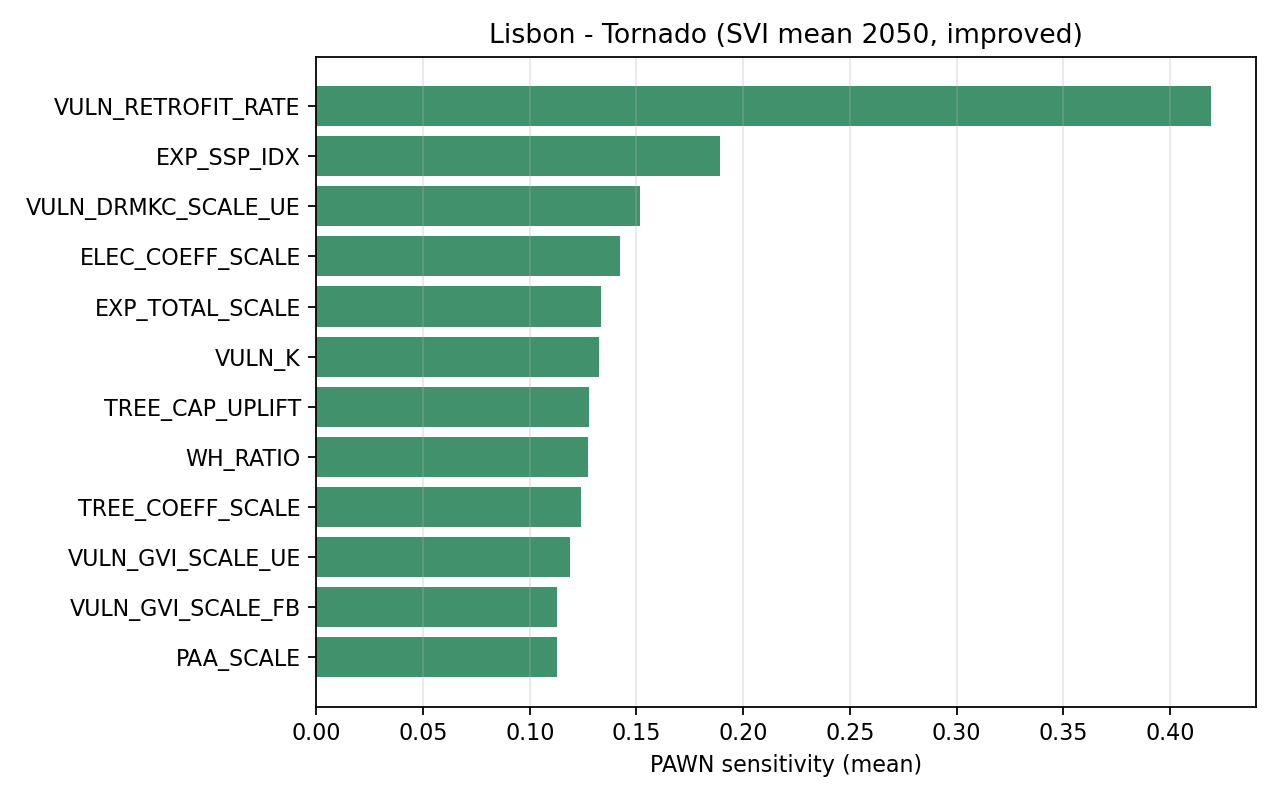

Generated headline figures displayed: 11

In [7]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

display(Markdown('## Masselot-main NB09 output paths'))
for _k, _v in sorted(paths.items()):
    display(Markdown(f'- {_k}: {_v}'))

samples = pd.read_csv(paths['samples'])
display(Markdown('## Headline sample IF-family counts'))
if 'if_family' in samples.columns:
    display(samples['if_family'].value_counts().rename_axis('if_family').to_frame('n'))

fig_dir = Path(paths['samples']).parent
fig_order = [
    'unc_distribution_aai_agg_lisbon_improved_fast.png',
    'unc_cdf_aai_agg_lisbon_improved_fast.png',
    'sens_tornado_aai_agg_lisbon_improved_fast.png',
    'unc_distribution_cba_ews_lisbon_improved_fast.png',
    'unc_cdf_cba_ews_lisbon_improved_fast.png',
    'sens_tornado_cba_ews_lisbon_improved_fast.png',
    'unc_freq_curve_lisbon_improved_fast.png',
    'unc_distribution_vuln_svi_mean_lisbon_improved_fast.png',
    'unc_distribution_vuln_2050_svi_mean_lisbon_improved_fast.png',
    'sens_tornado_vuln_svi_gap_lisbon_improved_fast.png',
    'sens_tornado_vuln_svi_mean_lisbon_improved_fast.png',
]
display(Markdown('## Generated headline NB09 figures'))
shown = 0
for fig_name in fig_order:
    fig_path = fig_dir / fig_name
    if fig_path.exists():
        display(Markdown(f'### {fig_name}'))
        display(Image(filename=str(fig_path)))
        shown += 1
display(Markdown(f'Generated headline figures displayed: {shown}'))